### 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


### 2. Carregamento da base bruta e das dimensões

Lemos a base de fatos bruta (`exportacoes.parquet`) e as dimensões já construídas no notebook de
transformação (`dim_estado`, `dim_pais`, `dim_ncm`). O bloco abaixo procura os arquivos em alguns
caminhos comuns para funcionar independente de onde o notebook é executado.

In [2]:
def achar_data_path():
    candidatos = [Path('../data/processed'), Path('data/processed'), Path('.')]
    for p in candidatos:
        if (p / 'exportacoes.parquet').exists():
            return p
    raise FileNotFoundError('Nao encontrei exportacoes.parquet. Ajuste DATA_PATH manualmente.')

DATA_PATH = achar_data_path()
print('Lendo de:', DATA_PATH.resolve())

df = pd.read_parquet(DATA_PATH / 'exportacoes.parquet')
dim_estado = pd.read_parquet(DATA_PATH / 'dim_estado.parquet')
dim_pais   = pd.read_parquet(DATA_PATH / 'dim_pais.parquet')
dim_ncm    = pd.read_parquet(DATA_PATH / 'dim_ncm.parquet')

print('Base bruta:', df.shape)
df.head()

Lendo de: /home/claude/projeto/data/processed


Base bruta: (5561220, 13)


,co_ano,co_mes,co_ncm,co_unid,co_pais,sg_uf_ncm,co_via,co_urf,qt_estat,kg_liquido,vl_fob,ano_arquivo,valor_medio_kg
0,2023,3,84139190,10,160,RJ,4,817700,107365,5,20,2023,4.00
1,2023,12,73182100,10,764,SP,1,817800,0,0,84,2023,NaN
2,2023,4,84219999,10,40,RS,4,817600,2,2,758,2023,379.00
3,2023,5,85291090,10,63,RJ,7,1017503,1,1,275,2023,275.00
4,2023,10,84825010,11,63,MG,7,1017503,2,0,9,2023,NaN


### 3. Diagnóstico inicial da qualidade dos dados
Antes de tratar, verificamos tipos, nulos e valores inconsistentes.

In [3]:
print('Dimensoes:', df.shape)
print('\nTipos:')
print(df.dtypes)
print('\nValores nulos por coluna:')
print(df.isnull().sum())
print('\nRegistros com vl_fob <= 0:', int((df.vl_fob <= 0).sum()))
print('Registros com kg_liquido <= 0:', int((df.kg_liquido <= 0).sum()))
print('\nAnos disponiveis:')
print(df.co_ano.value_counts().sort_index())

Dimensoes: (5561220, 13)

Tipos:
co_ano              int64
co_mes              int64
co_ncm              int64
co_unid             int64
co_pais             int64
sg_uf_ncm             str
co_via              int64
co_urf              int64
qt_estat            int64
kg_liquido          int64
vl_fob              int64
ano_arquivo           str
valor_medio_kg    float64
dtype: object

Valores nulos por coluna:
co_ano                 0
co_mes                 0
co_ncm                 0
co_unid                0
co_pais                0
sg_uf_ncm              0
co_via                 0
co_urf                 0
qt_estat               0
kg_liquido             0
vl_fob                 0
ano_arquivo            0
valor_medio_kg    427920
dtype: int64

Registros com vl_fob <= 0: 13004
Registros com kg_liquido <= 0: 427920

Anos disponiveis:
co_ano
2023    1563659
2024    1603796
2025    1709746
2026     684019
Name: count, dtype: int64


### 4. Tratamento da base (limpeza e enriquecimento)

**Decisões de tratamento:**

1. **Remoção de registros inválidos:** linhas com `vl_fob <= 0` ou `kg_liquido <= 0` são removidas.
   Sem peso ou sem valor não é possível calcular valor agregado por kg, métrica central da análise.
2. **Recálculo de `valor_medio_kg`** = `vl_fob / kg_liquido` (US$ por kg) após a limpeza.
3. **Enriquecimento** com nomes legíveis vindos das dimensões (região, país) e criação de variáveis
   derivadas: `ncm_capitulo` (2 primeiros dígitos da NCM = capítulo do produto), `categoria_produto`
   (nome do capítulo), `via_nome` (modal de transporte) e `trimestre`.

In [4]:
df = df.copy()

# --- padronizacao de chaves ---
df['sg_uf_ncm'] = df['sg_uf_ncm'].astype(str)
df['co_ncm_str'] = df['co_ncm'].astype(str).str.zfill(8)
df['ncm_capitulo'] = df['co_ncm_str'].str[:2]

# --- 1. remocao de registros invalidos ---
n0 = len(df)
df = df[(df.vl_fob > 0) & (df.kg_liquido > 0)].copy()
print(f'Registros removidos (vl_fob/kg invalidos): {n0 - len(df):,}  ({(n0-len(df))/n0*100:.1f}%)')
print(f'Registros validos restantes: {len(df):,}')

# --- 2. recalculo do valor por kg ---
df['valor_medio_kg'] = df['vl_fob'] / df['kg_liquido']

# --- 3. enriquecimento ---
df = df.merge(dim_estado[['sg_uf_ncm', 'estado', 'regiao']], on='sg_uf_ncm', how='left')
df = df.merge(dim_pais[['co_pais', 'nome_pais']], on='co_pais', how='left')

# nome do modal de transporte (via)
via_map = {1:'Maritima', 2:'Fluvial', 3:'Lacustre', 4:'Aerea', 5:'Postal',
           6:'Ferroviaria', 7:'Rodoviaria', 8:'Conduto', 9:'Meios Proprios',
           10:'Ficta', 11:'Courier', 12:'Em Maos', 14:'Reboque', 15:'Dutos', 0:'Nao Informado'}
df['via_nome'] = df['co_via'].map(via_map).fillna('Outros')

# nome do capitulo NCM (principais capitulos da pauta brasileira)
cap_map = {
    '27':'Combustiveis minerais', '12':'Sementes/oleaginosas (soja)', '26':'Minerios (ferro)',
    '02':'Carnes', '17':'Acucares', '84':'Maquinas/equipamentos', '87':'Veiculos',
    '72':'Ferro e aco', '09':'Cafe/cha/especiarias', '47':'Pasta de madeira/celulose',
    '10':'Cereais', '23':'Residuos ind. alimentar', '15':'Gorduras e oleos', '44':'Madeira',
    '88':'Aeronaves', '39':'Plasticos', '29':'Quimicos organicos', '71':'Pedras/metais preciosos'
}
df['categoria_produto'] = df['ncm_capitulo'].map(cap_map).fillna('Outros produtos')

# trimestre
df['trimestre'] = ((df['co_mes'] - 1) // 3) + 1

print('\nNulos apos enriquecimento (regiao/pais):',
      int(df.regiao.isnull().sum()), '/', int(df.nome_pais.isnull().sum()))
df[['co_ano','co_mes','regiao','nome_pais','categoria_produto','via_nome','vl_fob','kg_liquido','valor_medio_kg']].head()

Registros removidos (vl_fob/kg invalidos): 431,417  (7.8%)
Registros validos restantes: 5,129,803



Nulos apos enriquecimento (regiao/pais): 0 / 0


,co_ano,co_mes,regiao,nome_pais,categoria_produto,via_nome,vl_fob,kg_liquido,valor_medio_kg
0,2023,3,REGIAO SUDESTE,China,Maquinas/equipamentos,Aerea,20,5,4.00
1,2023,4,REGIAO SUL,Angola,Maquinas/equipamentos,Aerea,758,2,379.00
2,2023,5,REGIAO SUDESTE,Argentina,Outros produtos,Rodoviaria,275,1,275.00
3,2023,8,REGIAO SUL,Guatemala,Outros produtos,Aerea,444,56,7.93
4,2023,3,REGIAO NORTE,Hong Kong,Carnes,Maritima,667,170,3.92


### 5. Visão geral estatística da base tratada

In [5]:
print('Periodo:', df.co_ano.min(), 'a', df.co_ano.max(),
      '| (2026 e parcial: meses', sorted(df[df.co_ano==2026].co_mes.unique()), ')')
print(f'Valor total exportado (US$): {df.vl_fob.sum():,.0f}')
print(f'Peso total (kg): {df.kg_liquido.sum():,.0f}')
print(f'Paises de destino: {df.nome_pais.nunique()}')
print(f'Produtos (NCM): {df.co_ncm.nunique()}')
print('\nEstatisticas das variaveis numericas:')
df[['vl_fob','kg_liquido','valor_medio_kg']].describe([.25,.5,.75,.9,.95]).T

Periodo: 2023 a 2026 | (2026 e parcial: meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] )
Valor total exportado (US$): 1,173,121,729,807
Peso total (kg): 2,800,836,481,759
Paises de destino: 248
Produtos (NCM): 8670

Estatisticas das variaveis numericas:


,count,mean,std,min,25%,50%,75%,90%,95%,max
vl_fob,"5,129,803.00","228,687.48","5,348,782.57",1.00,119.00,"1,047.00","14,605.00","101,120.00","289,175.00","1,309,004,663.00"
kg_liquido,"5,129,803.00","545,992.99","38,909,797.61",1.00,9.00,53.00,"1,255.00","27,600.00","108,120.00","14,646,306,000.00"
valor_medio_kg,"5,129,803.00",376.73,"79,428.20",0.00,2.81,9.08,36.00,138.50,345.80,"72,078,736.00"


### 6. EDA — Gráfico 1: DISTRIBUIÇÃO

As variáveis monetárias têm forte assimetria (muitas transações pequenas, poucas gigantes), então
usamos **escala logarítmica** para visualizar a distribuição com clareza.

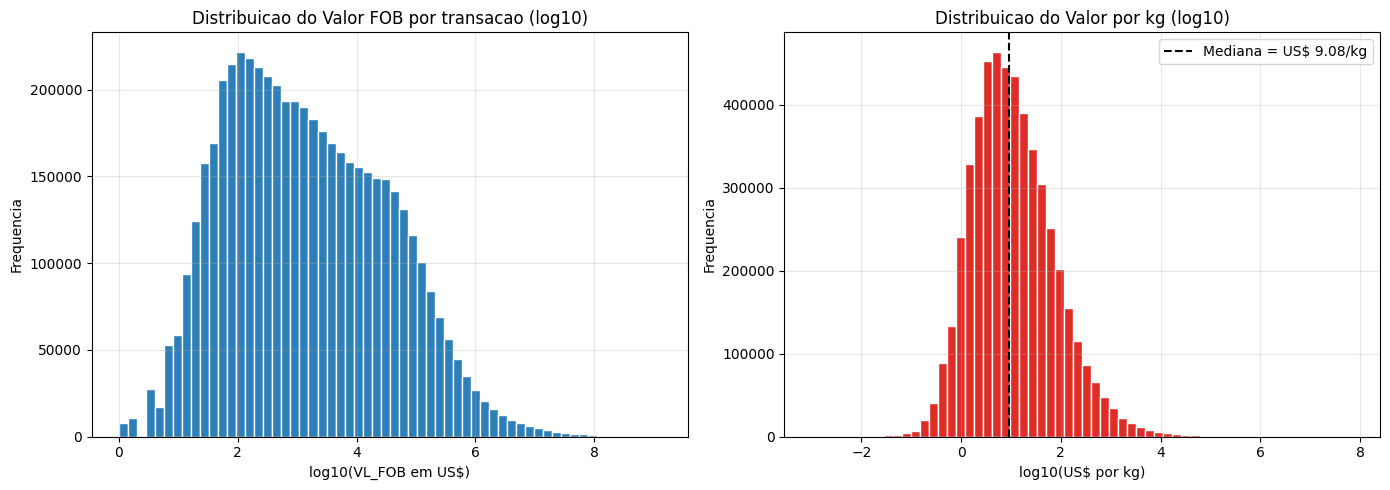

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribuicao do valor FOB (log)
axes[0].hist(np.log10(df.vl_fob), bins=60, color='#2c7fb8', edgecolor='white')
axes[0].set_title('Distribuicao do Valor FOB por transacao (log10)')
axes[0].set_xlabel('log10(VL_FOB em US$)')
axes[0].set_ylabel('Frequencia')

# distribuicao do valor por kg (log) -- proxy de valor agregado
axes[1].hist(np.log10(df.valor_medio_kg.clip(lower=1e-3)), bins=60, color='#de2d26', edgecolor='white')
axes[1].axvline(np.log10(df.valor_medio_kg.median()), color='black', linestyle='--',
                label=f'Mediana = US$ {df.valor_medio_kg.median():.2f}/kg')
axes[1].set_title('Distribuicao do Valor por kg (log10)')
axes[1].set_xlabel('log10(US$ por kg)')
axes[1].set_ylabel('Frequencia')
axes[1].legend()

plt.tight_layout()
plt.show()

**Leitura:** o valor FOB segue distribuição aproximadamente log-normal. O valor por kg
(indicador de **valor agregado**) tem mediana de ~US$ 9/kg: metade das transações é de produtos
de baixo valor agregado (commodities) e metade de produtos mais elaborados.

### 7. EDA — Gráfico 2: COMPARAÇÃO ENTRE CATEGORIAS

Comparamos o valor exportado entre regiões, modais de transporte, países de destino e categorias de produto.

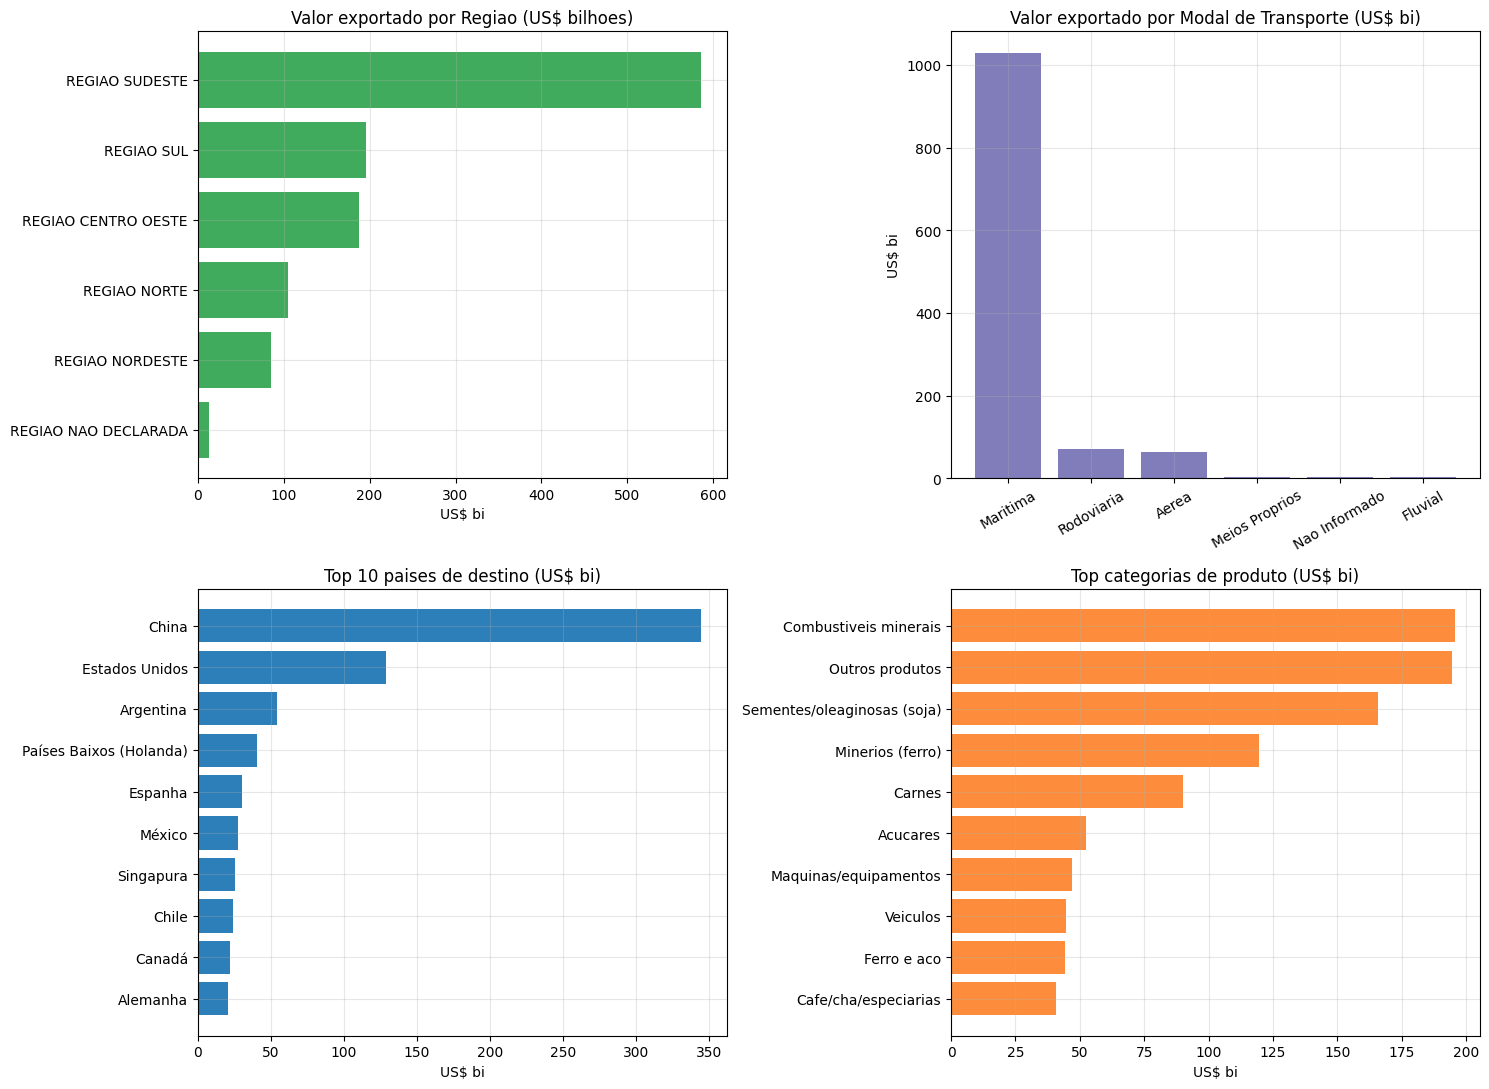

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (a) VL_FOB por regiao
reg = df.groupby('regiao').vl_fob.sum().sort_values() / 1e9
axes[0,0].barh(reg.index, reg.values, color='#41ab5d')
axes[0,0].set_title('Valor exportado por Regiao (US$ bilhoes)')
axes[0,0].set_xlabel('US$ bi')

# (b) VL_FOB por via
via = df.groupby('via_nome').vl_fob.sum().sort_values(ascending=False).head(6) / 1e9
axes[0,1].bar(via.index, via.values, color='#807dba')
axes[0,1].set_title('Valor exportado por Modal de Transporte (US$ bi)')
axes[0,1].set_ylabel('US$ bi')
axes[0,1].tick_params(axis='x', rotation=30)

# (c) Top 10 paises de destino
pais = df.groupby('nome_pais').vl_fob.sum().sort_values(ascending=False).head(10) / 1e9
axes[1,0].barh(pais.index[::-1], pais.values[::-1], color='#2c7fb8')
axes[1,0].set_title('Top 10 paises de destino (US$ bi)')
axes[1,0].set_xlabel('US$ bi')

# (d) Top categorias de produto
cat = df.groupby('categoria_produto').vl_fob.sum().sort_values(ascending=False).head(10) / 1e9
axes[1,1].barh(cat.index[::-1], cat.values[::-1], color='#fd8d3c')
axes[1,1].set_title('Top categorias de produto (US$ bi)')
axes[1,1].set_xlabel('US$ bi')

plt.tight_layout()
plt.show()

### 8. EDA — Comparação do valor agregado (US$/kg) entre categorias

Além do valor total, comparamos a **mediana do valor por kg** entre modais e regiões — isso revela
*onde* está o produto de maior valor agregado, não apenas o maior volume.

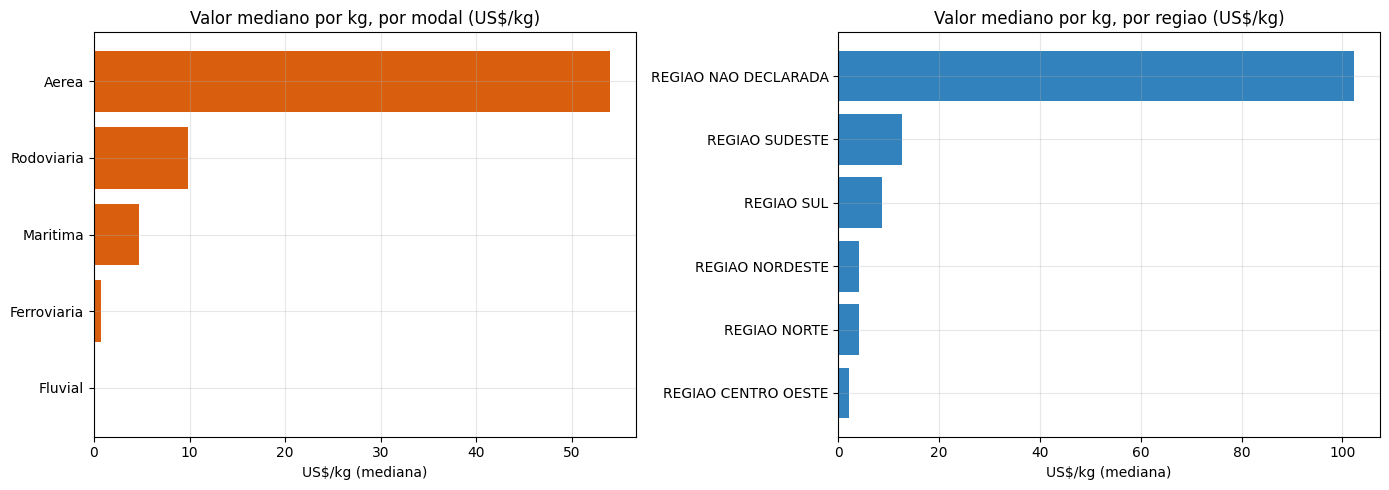

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vkg_via = (df[df.via_nome.isin(['Maritima','Aerea','Rodoviaria','Ferroviaria','Fluvial','Courier'])]
           .groupby('via_nome').valor_medio_kg.median().sort_values())
axes[0].barh(vkg_via.index, vkg_via.values, color='#d95f0e')
axes[0].set_title('Valor mediano por kg, por modal (US$/kg)')
axes[0].set_xlabel('US$/kg (mediana)')

vkg_reg = df.groupby('regiao').valor_medio_kg.median().sort_values()
axes[1].barh(vkg_reg.index, vkg_reg.values, color='#3182bd')
axes[1].set_title('Valor mediano por kg, por regiao (US$/kg)')
axes[1].set_xlabel('US$/kg (mediana)')

plt.tight_layout()
plt.show()

### 9. EDA — Gráfico 3: EVOLUÇÃO TEMPORAL

Série mensal do valor total exportado. **Atenção:** 2026 está incompleto (apenas jan–mai),
então a queda no fim da série é por falta de meses, não por retração real.

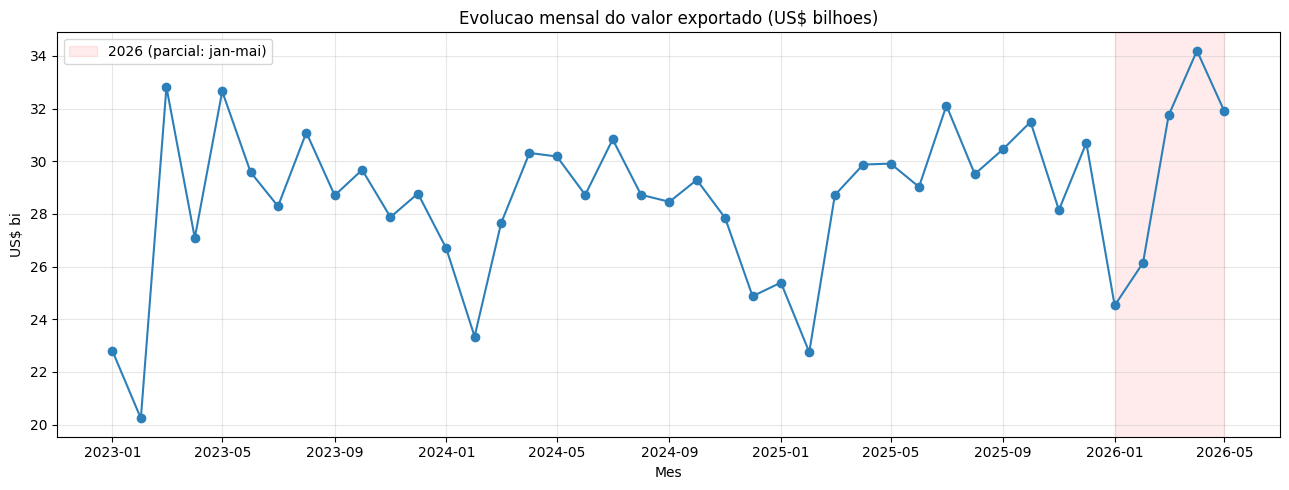

Valor total por ano (US$ bi):
co_ano
2023   339.60
2024   336.90
2025   348.10
2026   148.50
Name: vl_fob, dtype: float64


In [9]:
serie = (df.groupby(['co_ano','co_mes']).vl_fob.sum() / 1e9).reset_index()
serie['data'] = pd.to_datetime(dict(year=serie.co_ano, month=serie.co_mes, day=1))
serie = serie.sort_values('data')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie.data, serie.vl_fob, marker='o', color='#2c7fb8')
corte = pd.Timestamp('2026-01-01')
ax.axvspan(corte, serie.data.max(), color='red', alpha=0.08, label='2026 (parcial: jan-mai)')
ax.set_title('Evolucao mensal do valor exportado (US$ bilhoes)')
ax.set_xlabel('Mes'); ax.set_ylabel('US$ bi')
ax.legend()
plt.tight_layout()
plt.show()

# total por ano (comparacao)
print('Valor total por ano (US$ bi):')
print((df.groupby('co_ano').vl_fob.sum()/1e9).round(1))

### 10. Insights de Negócio (a partir da EDA)

> Os números abaixo são calculados na própria célula para garantir consistência com a base tratada.

In [10]:
total = df.vl_fob.sum()
top_pais = df.groupby('nome_pais').vl_fob.sum().sort_values(ascending=False)
top_reg  = df.groupby('regiao').vl_fob.sum().sort_values(ascending=False)
share_china = top_pais.iloc[0]/total*100
share_top5  = top_pais.head(5).sum()/total*100
share_sudeste = top_reg.iloc[0]/total*100
vkg_aerea = df[df.via_nome=='Aerea'].valor_medio_kg.median()
vkg_marit = df[df.via_nome=='Maritima'].valor_medio_kg.median()

print(f'1. CONCENTRACAO EM DESTINO: a China responde por {share_china:.1f}% de todo o valor exportado;')
print(f'   os 5 maiores destinos somam {share_top5:.1f}%. Alta dependencia de poucos compradores.')
print()
print(f'2. CONCENTRACAO REGIONAL: a regiao {top_reg.index[0].title()} concentra {share_sudeste:.1f}%')
print(f'   das exportacoes em valor, evidenciando desigualdade regional na pauta exportadora.')
print()
print(f'3. PERFIL DE COMMODITY: os capitulos lideres sao combustiveis, soja, minerios e carnes')
print(f'   -- produtos de baixo valor agregado, escoados majoritariamente por via maritima.')
print()
print(f'4. VALOR AGREGADO x MODAL: o modal aereo tem valor mediano de US$ {vkg_aerea:.0f}/kg,')
print(f'   ~{vkg_aerea/vkg_marit:.0f}x o maritimo (US$ {vkg_marit:.1f}/kg). Produto nobre voa, commodity navega.')
print()
print(f'5. ESTABILIDADE ANUAL: 2023-2025 ficaram estaveis (~US$ 340 bi/ano), sem crescimento real,')
print(f'   sinal de pauta madura e dependente de preco de commodities.')

1. CONCENTRACAO EM DESTINO: a China responde por 29.4% de todo o valor exportado;
   os 5 maiores destinos somam 51.1%. Alta dependencia de poucos compradores.

2. CONCENTRACAO REGIONAL: a regiao Regiao Sudeste concentra 50.0%
   das exportacoes em valor, evidenciando desigualdade regional na pauta exportadora.

3. PERFIL DE COMMODITY: os capitulos lideres sao combustiveis, soja, minerios e carnes
   -- produtos de baixo valor agregado, escoados majoritariamente por via maritima.

4. VALOR AGREGADO x MODAL: o modal aereo tem valor mediano de US$ 54/kg,
   ~11x o maritimo (US$ 4.7/kg). Produto nobre voa, commodity navega.

5. ESTABILIDADE ANUAL: 2023-2025 ficaram estaveis (~US$ 340 bi/ano), sem crescimento real,
   sinal de pauta madura e dependente de preco de commodities.


**Decisões de negócio sugeridas (item 7 do projeto):**

- **Diversificar destinos:** a dependência da China é um risco geopolítico/cambial; políticas de
  promoção comercial deveriam priorizar novos mercados (Sudeste Asiático, África, Oriente Médio).
- **Agregar valor:** incentivar industrialização da pauta (ex.: exportar farelo/óleo em vez de grão,
  produto manufaturado em vez de minério) elevaria o US$/kg e reduziria a exposição a preço de commodity.
- **Reduzir desigualdade regional:** infraestrutura logística no Norte/Nordeste/Centro-Oeste para
  destravar potencial exportador fora do Sudeste/Sul.

### 11. Exportação da base analítica tratada
Salvamos a base limpa e enriquecida para ser consumida diretamente pelo notebook de Machine Learning.

In [11]:
saida = DATA_PATH / 'base_analitica.parquet'
colunas = ['co_ano','co_mes','trimestre','regiao','estado','nome_pais',
           'ncm_capitulo','categoria_produto','via_nome','co_via',
           'qt_estat','kg_liquido','vl_fob','valor_medio_kg']
df[colunas].to_parquet(saida, index=False)
print('Base analitica tratada salva em:', saida.resolve())
print('Shape final:', df[colunas].shape)

Base analitica tratada salva em: /home/claude/projeto/data/processed/base_analitica.parquet
Shape final: (5129803, 14)
